In [1]:
import os, sys

# Locate the scripts directory regardless of CWD
_candidates = [
    os.path.abspath(""),                                     # CWD is scripts dir
    os.path.join(os.path.abspath(""), "data", "scripts"),    # CWD is project root
]
for _d in _candidates:
    if os.path.isfile(os.path.join(_d, "config.py")):
        sys.path.insert(0, _d)
        break

import ipywidgets as widgets
from IPython.display import clear_output, display

from config import (
    RAW_DATA_DIR, RAIL_ROUTE_TYPES, ANALYSIS_DATE,
    MAX_ELAPSED_MINUTES, START_STATION_NAME,
)
from data_loader import (
    load_stops, load_routes, load_trips, load_calendar,
    load_calendar_dates, load_stop_times_basic, load_stop_times_hourly,
    filter_rail_routes, filter_rail_trips, filter_rail_stop_ids,
    build_station_meta, derive_station_key, services_active_on_date,
)
from spatial import load_swiss_boundary, filter_stops_within_switzerland, filter_rail_stations
from reachability import (
    build_walking_neighbors,
    compute_active_services, compute_active_rail_trips,
    load_active_stop_times, build_trip_graph,
    ReachabilityEngine, resolve_start_station,
)
from visualization import (
    apply_mpl_defaults, plot_stops_map, plot_rail_stations_map,
    plot_busiest_stops, plot_reachability_map, plot_station_meta_map,
)

apply_mpl_defaults()

## 0. Data downloading

please make sure you have downloaded the raw data by running the `data/scripts/data_downloader.py`.


## 1. Load Stops & Basic Inspection

In [2]:
stops_df = load_stops()

print(f"Total stops: {len(stops_df)}")
display(stops_df.head(3))
print(f"Lat range: {stops_df['stop_lat'].min()} – {stops_df['stop_lat'].max()}")
print(f"Lon range: {stops_df['stop_lon'].min()} – {stops_df['stop_lon'].max()}")

# Example: stops outside Switzerland
western = stops_df[stops_df["stop_lon"] < 5.0][["stop_name", "stop_lat", "stop_lon"]]
print(f"\nStops with lon < 5° (cross-border examples):")
display(western.head(10))

Total stops: 96949


,stop_id,stop_name,stop_lat,stop_lon,location_type,parent_station,platform_code,original_stop_id
0,1100008,"Zell (Wiesental), Wilder Mann",47.710084,7.859648,NaN,Parent1100008,NaN,ch:1:sloid:1100008
1,1100009,"Zell (Wiesental), Grönland",47.713191,7.862909,NaN,Parent1100009,NaN,ch:1:sloid:1100009
2,1100010,Atzenbach,47.714618,7.872350,NaN,Parent1100010,NaN,ch:1:sloid:1100010


Lat range: 42.69594173 – 52.37907805
Lon range: -4.47981747 – 14.4360434

Stops with lon < 5° (cross-border examples):


,stop_name,stop_lat,stop_lon
8304,"Les Aubrais, gare routiere",47.926664,1.907501
8329,"Voué, Mairie",48.457662,4.122899
8330,"Arcis-Sur-Aube, Rue De Chalons",48.537452,4.141710
8331,"Mailly-Le-Camp, Garage",48.674754,4.188889
8332,"Sommesous, Route Nationale",48.737349,4.205849
8333,"Vatry, Rue Principale",48.821117,4.244037
8478,"Iguerande, Bourg",46.203199,4.080804
8479,"Oingt, Route de Saint-Laurent",45.946113,4.581390
8480,"Saint-Laurent-d'Oingt, Bourg",45.945276,4.563612
8481,"Saint-Laurent-d'Oingt, Gare",45.932220,4.551665


## 2. Spatial Filtering — Swiss Boundary

The dataset contains cross-border stops (e.g. France, Germany).
We use the official **SwissBoundaries3D** outline via Point-in-Polygon to keep only domestic stops.

Total stops:   96,949
Inside CH:     75,910
Removed:       21,039


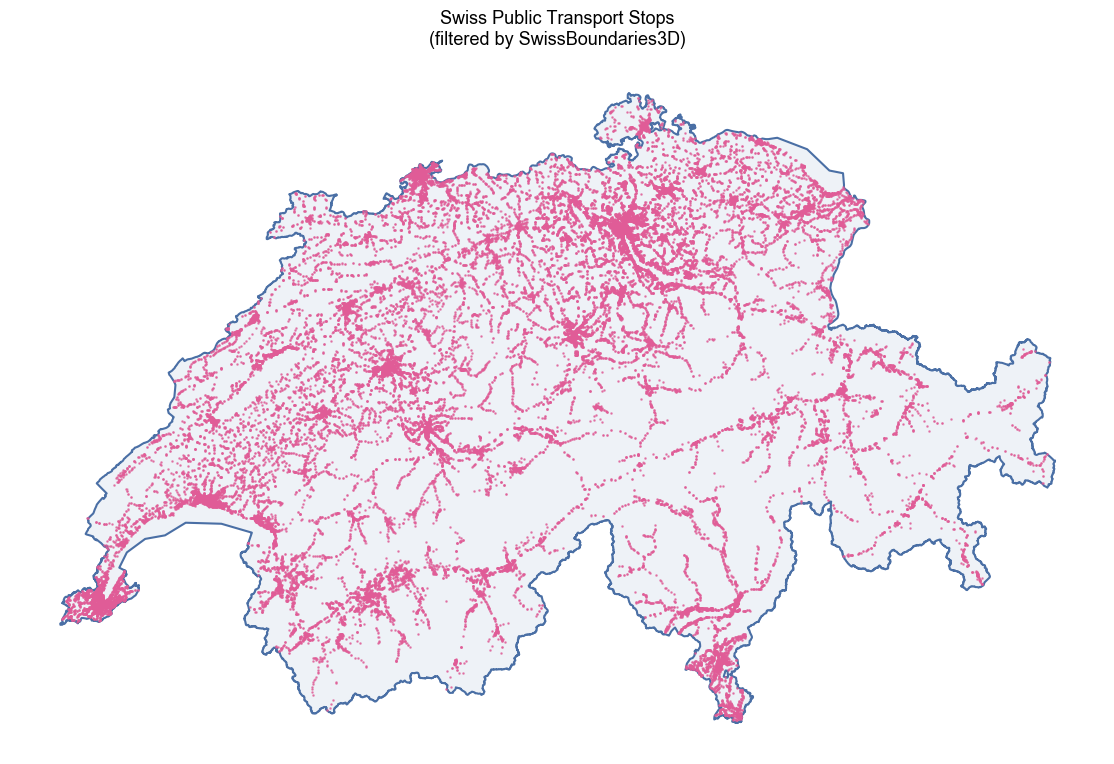

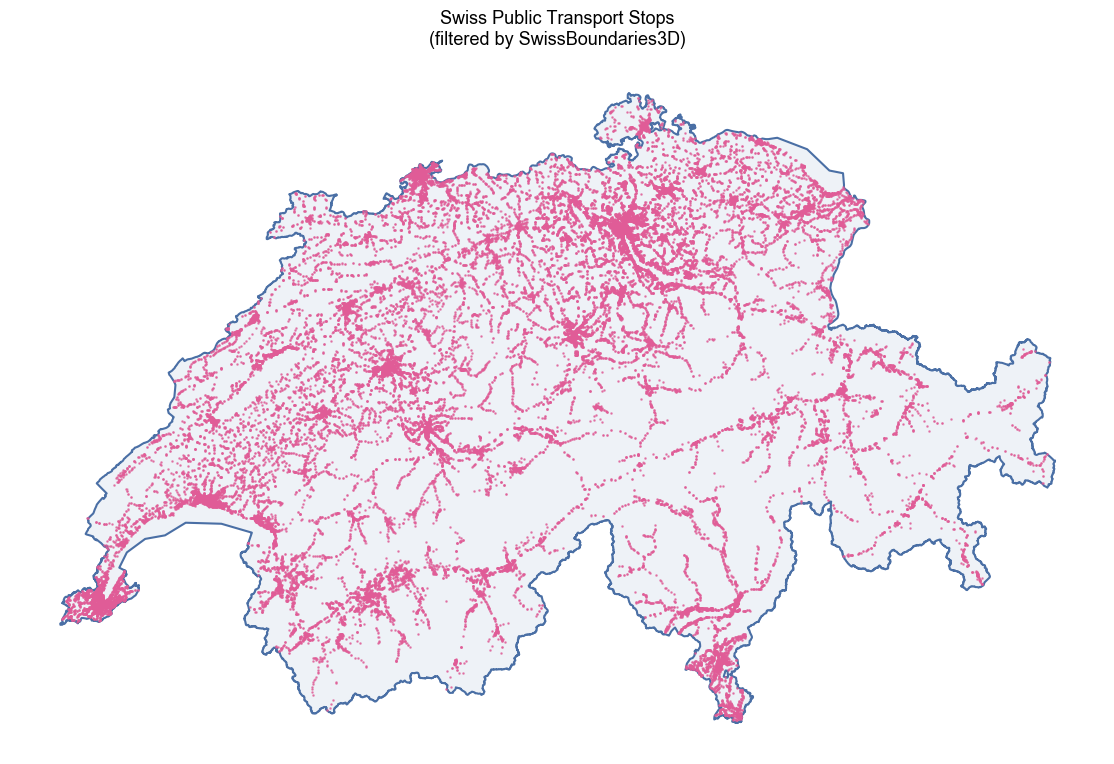

In [3]:
swiss_boundary, swiss_boundary_proj = load_swiss_boundary()
stops_inside = filter_stops_within_switzerland(stops_df, swiss_boundary)

print(f"Total stops:   {len(stops_df):,}")
print(f"Inside CH:     {len(stops_inside):,}")
print(f"Removed:       {len(stops_df) - len(stops_inside):,}")

plot_stops_map(stops_inside, swiss_boundary_proj)

## 3. Rail Station Extraction

Stops inside CH:   75,910
Rail stations:     3,604
Non-rail stops:    72,306


,stop_name,stop_lat,stop_lon
9308,Basel SBB,47.547413,7.589560
9309,Basel SBB,47.546594,7.592139
9310,Basel SBB,47.545988,7.591716
9311,Basel SBB,47.546788,7.589093
9312,Basel SBB,47.546788,7.589093


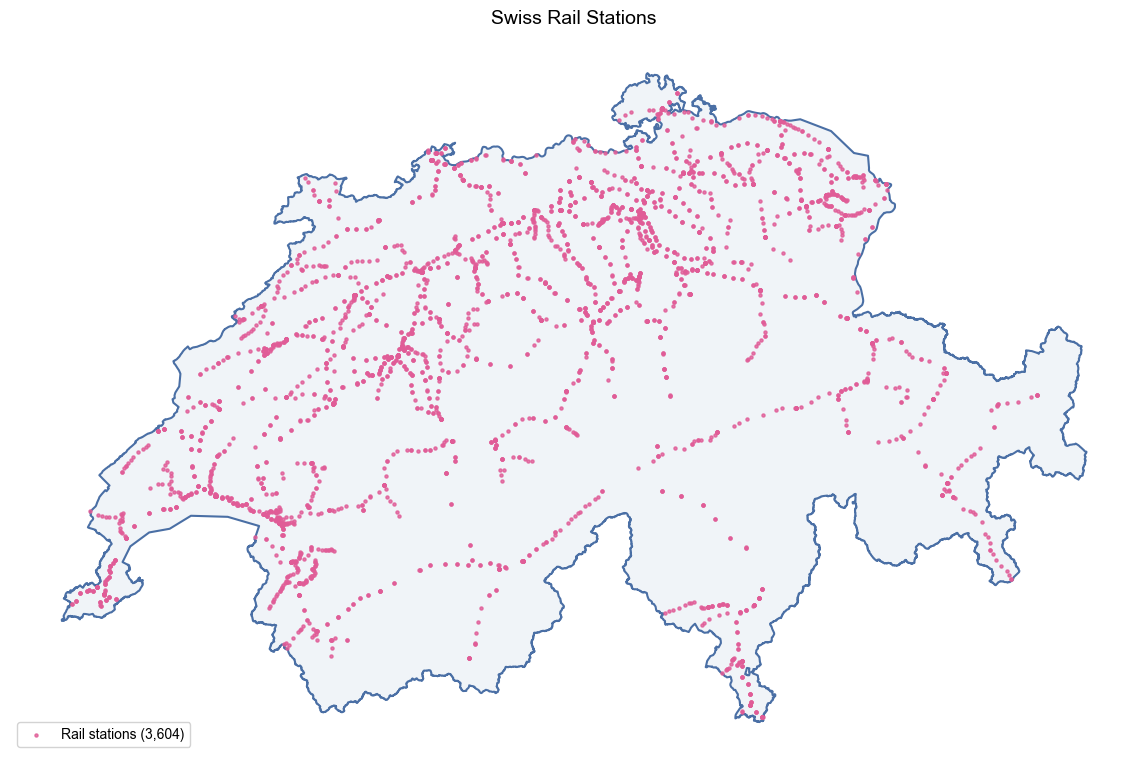

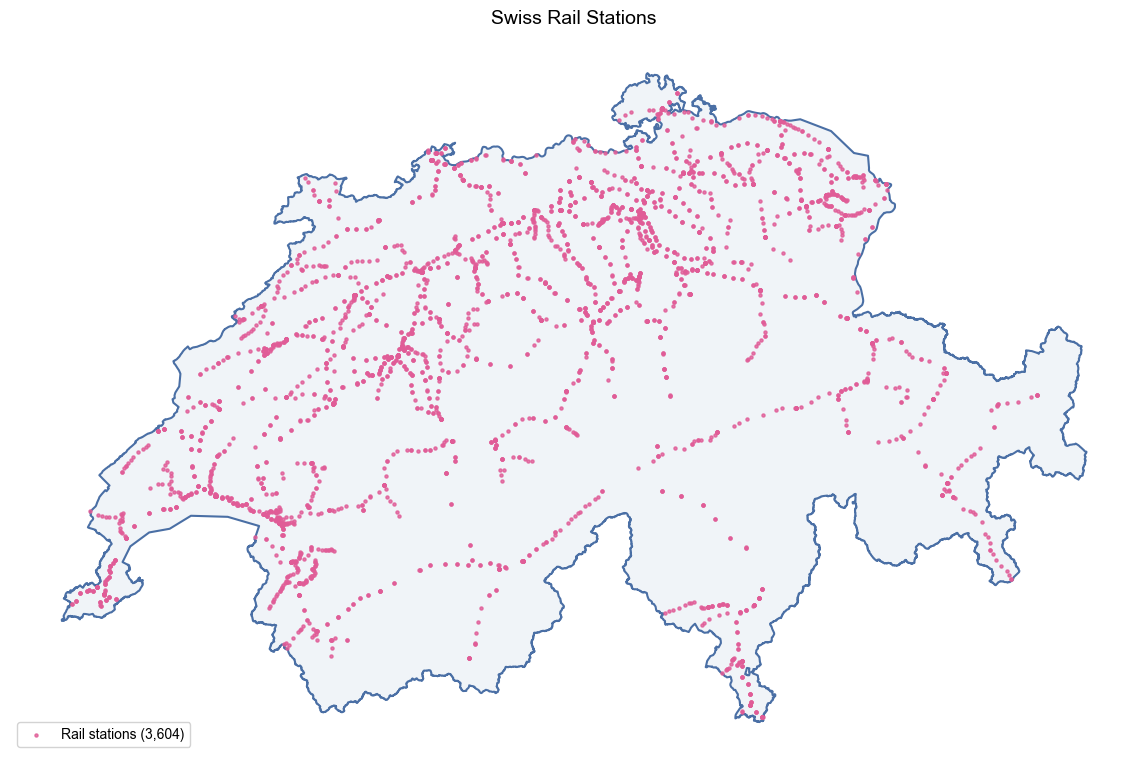

In [4]:
routes_df = load_routes()
trips_df  = load_trips()

rail_routes   = filter_rail_routes(routes_df)
rail_trips    = filter_rail_trips(trips_df, rail_routes)
rail_stop_ids = filter_rail_stop_ids(load_stop_times_basic(), rail_trips)

train_stations_df = filter_rail_stations(stops_inside, rail_stop_ids)

print(f"Stops inside CH:   {len(stops_inside):,}")
print(f"Rail stations:     {len(train_stations_df):,}")
print(f"Non-rail stops:    {len(stops_inside) - len(train_stations_df):,}")
display(train_stations_df[["stop_name", "stop_lat", "stop_lon"]].head())

plot_rail_stations_map(train_stations_df, swiss_boundary_proj)

### 3a. Platform Deduplication

GTFS encodes each **platform / entrance** as a separate `stop_id`, so major hubs like *Basel SBB* or *Zürich HB* appear dozens of times with slightly different coordinates. For map-level visualisation and reachability analysis the platform distinction is irrelevant — what matters is the **logical station**.

We use the GTFS `parent_station` field (falling back to `stop_id` when absent) as a canonical station key and keep one representative coordinate per station. All subsequent analyses use this deduplicated table.

Top 10 stations by number of GTFS stop entries (platforms / entrances):


,stop_name,platform_count
0,Luzern,41
1,Basel SBB,34
2,Bern,32
3,Zürich HB,26
4,Biel/Bienne,25
5,Olten,20
6,Chur,20
7,Winterthur,16
8,Rapperswil SG,15
9,Klosters Platz,14



Raw stop entries (incl. individual platforms): 3,604
Unique logical stations after deduplication:   1,664
Entries collapsed:                             1,940


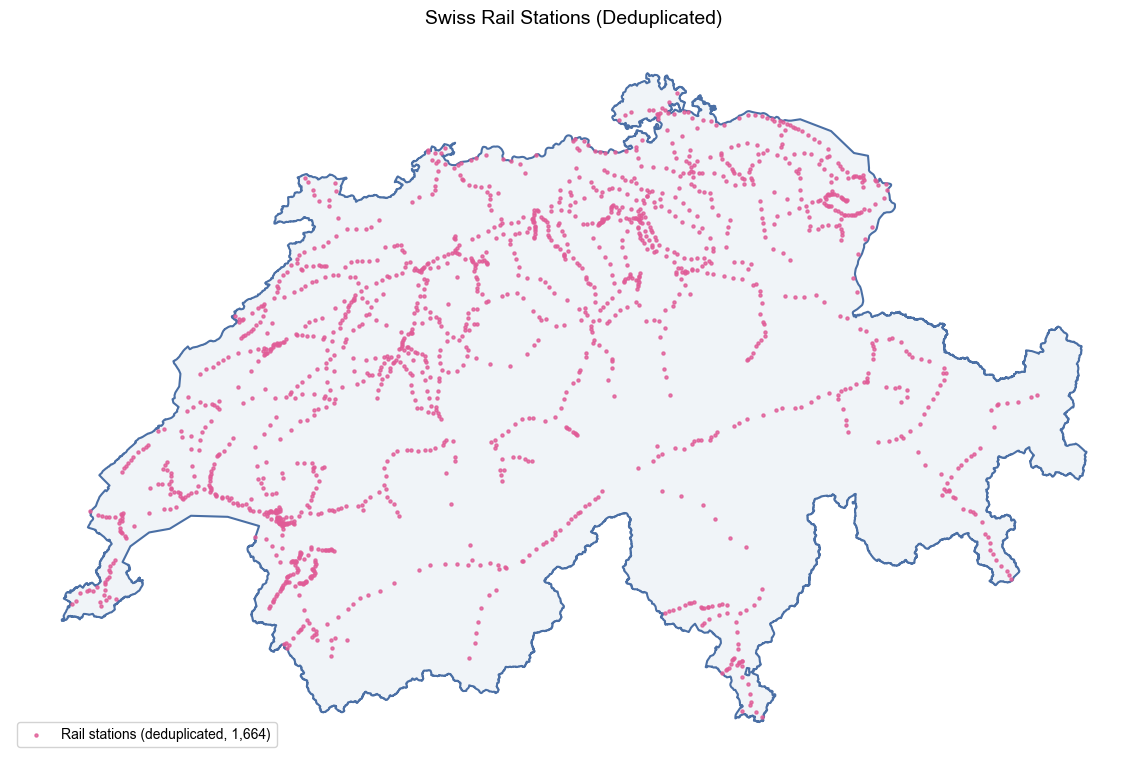

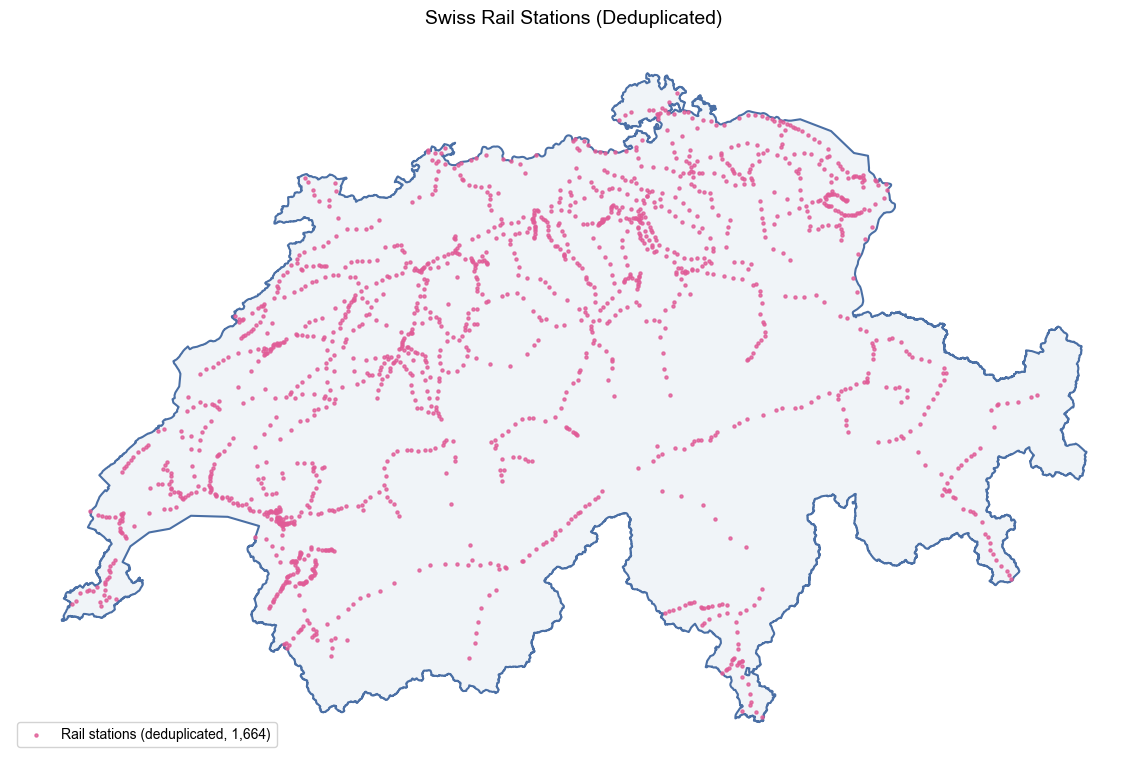

In [5]:
# ── Duplicate (platform-level) analysis ──────────────────────────────
name_counts = (
    train_stations_df
    .groupby("stop_name")
    .size()
    .sort_values(ascending=False)
    .rename("platform_count")
)

print("Top 10 stations by number of GTFS stop entries (platforms / entrances):")
display(name_counts.head(10).reset_index())

# Deduplicate: one representative coordinate per logical station
# Strategy: prefer the entry whose stop_id equals its parent_station (the "parent" node),
# then fall back to stop_id itself — exactly what build_station_meta() implements.
train_stations_dedup = build_station_meta(train_stations_df)

print(f"\nRaw stop entries (incl. individual platforms): {len(train_stations_df):,}")
print(f"Unique logical stations after deduplication:   {len(train_stations_dedup):,}")
print(f"Entries collapsed:                             {len(train_stations_df) - len(train_stations_dedup):,}")

plot_station_meta_map(train_stations_dedup, swiss_boundary_proj)

## 4. Busiest Rail Stations (interactive)

This chart counts unique active rail `trip_id`s per logical station on `ANALYSIS_DATE`, aggregated from platform-level GTFS stops. It is not the raw row count of `stop_times.txt`.

In [6]:
calendar_df = load_calendar()
cal_dates = load_calendar_dates()
active_services = services_active_on_date(calendar_df, cal_dates, ANALYSIS_DATE)
active_rail_trips = rail_trips[rail_trips["service_id"].isin(active_services)].copy()
active_trip_ids = set(active_rail_trips["trip_id"].astype(str).unique())

stops_with_keys = stops_df.copy()
stops_with_keys["stop_id"] = stops_with_keys["stop_id"].astype(str)
stops_with_keys["station_key"] = derive_station_key(stops_with_keys)
swiss_train_stop_ids = set(train_stations_df["stop_id"].astype(str).unique())
station_name_lookup = train_stations_dedup.set_index("station_key")["station_name"].to_dict()

stop_times_windowed = load_stop_times_hourly(
    trip_ids=active_trip_ids,
    stop_ids=swiss_train_stop_ids,
)
station_windowed = (
    stop_times_windowed
    .merge(stops_with_keys[["stop_id", "station_key"]], on="stop_id", how="left")
    .dropna(subset=["station_key"])
)

print(f"Date: {ANALYSIS_DATE.date()} | Active rail services: {len(active_services):,}")
print(f"Active rail trips: {len(active_trip_ids):,} | Rail stop-time records: {len(station_windowed):,}")
print("Metric: unique active rail trips per logical station within the selected minute-level time window.")


def _clock_text(total_minutes):
    total_minutes = int(total_minutes)
    hours, minutes = divmod(total_minutes, 60)
    return f"{hours:02d}:{minutes:02d}"


busiest_start_slider = widgets.IntSlider(
    value=6 * 60, min=0, max=23 * 60 + 59, step=1,
    description="Start", continuous_update=False,
)
busiest_end_slider = widgets.IntSlider(
    value=10 * 60, min=1, max=23 * 60 + 59, step=1,
    description="End", continuous_update=False,
)

busiest_window_label = widgets.HTML()
busiest_output = widgets.Output()


def _update_busiest_label(_=None):
    busiest_window_label.value = (
        f"<b>Window:</b> {_clock_text(busiest_start_slider.value)} - "
        f"{_clock_text(busiest_end_slider.value)}"
    )


def _render_busiest(_=None):
    with busiest_output:
        clear_output(wait=True)
        plot_busiest_stops(
            station_windowed,
            station_name_lookup,
            busiest_start_slider.value,
            busiest_end_slider.value,
            date_label=str(ANALYSIS_DATE.date()),
        )


for slider in (busiest_start_slider, busiest_end_slider):
    slider.observe(_update_busiest_label, names="value")
    slider.observe(_render_busiest, names="value")

_update_busiest_label()
display(
    widgets.VBox([
        widgets.HBox([busiest_start_slider, busiest_end_slider]),
        busiest_window_label,
        busiest_output,
    ])
)
_render_busiest()

Date: 2026-03-18 | Active rail services: 6,992
Active rail trips: 19,590 | Rail stop-time records: 163,375
Metric: unique active rail trips per logical station within the selected minute-level time window.


## 5. Reachability Analysis (from Lausanne)

- Scope: Swiss **rail stations** only (`route_type` 2 and 100–109).
- Source: GTFS Static timetable from `opentransportdata.swiss`.
- Parameters: **departure time** and **time window**, both defined at minute-level precision (up to 48 h).
- Minimum transfer dwell: 3 min; remaining on the same train incurs no transfer penalty.

In [7]:
# Build the time-expanded rail graph.
calendar_df = load_calendar()
cal_dates   = load_calendar_dates()

rail_trips_full = rail_trips.merge(
    rail_routes[["route_id", "route_short_name", "route_desc"]], on="route_id", how="left"
)

active_offsets   = compute_active_services(calendar_df, cal_dates, ANALYSIS_DATE, MAX_ELAPSED_MINUTES)
active_rail      = compute_active_rail_trips(rail_trips_full, active_offsets)
active_trip_ids  = set(active_rail["trip_id"].unique())

stops_df["station_key"] = derive_station_key(stops_df)
swiss_train_stop_ids = set(train_stations_df["stop_id"].unique())

active_st = load_active_stop_times(active_trip_ids, swiss_train_stop_ids, stops_df, active_rail)
trip_instances, departures_by_station, departure_times_by_station = build_trip_graph(active_st)

# Deduplicated station table from Section 3a.
swiss_train_meta = train_stations_dedup
all_stops_meta   = build_station_meta(stops_df)
start_key, start_row = resolve_start_station(swiss_train_meta, all_stops_meta, START_STATION_NAME)

# Walking model (optional): short transfers between nearby stations.
# Typical adult walking speed is about 5 km/h.
WALKING_SPEED_KMH = 5.0
MAX_WALK_MINUTES = 1200.0
walking_neighbors = build_walking_neighbors(
    swiss_train_meta,
    max_walk_minutes=MAX_WALK_MINUTES,
    walking_speed_kmh=WALKING_SPEED_KMH,
)

engine_transit_only = ReachabilityEngine(
    swiss_train_meta, trip_instances,
    departures_by_station, departure_times_by_station, start_key,
)
engine_with_walking = ReachabilityEngine(
    swiss_train_meta, trip_instances,
    departures_by_station, departure_times_by_station, start_key,
    walking_neighbors=walking_neighbors,
)

# Default mode for this notebook section: include walking.
engine = engine_with_walking

walk_edges = sum(len(v) for v in walking_neighbors.values()) // 2
print(f"Date: {ANALYSIS_DATE.date()} | Rail routes: {rail_routes['route_id'].nunique():,}")
print(f"Stations: {len(swiss_train_meta):,} | Trip instances: {len(trip_instances):,}")
print(f"Walking edges (<= {MAX_WALK_MINUTES:.0f} min): {walk_edges:,} @ {WALKING_SPEED_KMH:.1f} km/h")
print(f"Origin: {start_row['station_name']} ({start_key})")
display(engine.build_reachable_frame(8 * 60, 6 * 60).head())

Date: 2026-03-18 | Rail routes: 731
Stations: 1,664 | Trip instances: 44,854
Walking edges (<= 1200 min): 662,559 @ 5.0 km/h
Origin: Lausanne (Parent8501120)


,station_key,station_name,stop_lat,stop_lon,arrival_minutes,reachable,travel_minutes
0,Parent8506013,Aadorf,47.488394,8.902278,688.000000,True,208.000000
1,Parent8502113,Aarau,47.391362,8.051277,613.000000,True,133.000000
2,Parent8519685,Aarau Torfeld,47.393570,8.062811,623.827498,True,143.827498
3,Parent8504404,Aarberg,47.044153,7.278438,581.000000,True,101.000000
4,Parent8502000,Aarburg-Oftringen,47.320271,7.908220,615.000000,True,135.000000


In [8]:
departure_slider = widgets.IntSlider(
    value=8 * 60, min=0, max=23 * 60 + 59, step=1,
    description="Departure", continuous_update=False,
)
elapsed_slider = widgets.IntSlider(
    value=6 * 60, min=1, max=MAX_ELAPSED_MINUTES, step=1,
    description="Window", continuous_update=False,
)

walking_checkbox = widgets.Checkbox(
    value=True,
    description="Include walking links",
)

reachability_label = widgets.HTML()
reachability_output = widgets.Output()


def _clock_text(total_minutes):
    total_minutes = int(total_minutes)
    hours, minutes = divmod(total_minutes, 60)
    return f"{hours:02d}:{minutes:02d}"


def _duration_text(total_minutes):
    total_minutes = int(total_minutes)
    hours, minutes = divmod(total_minutes, 60)
    if hours and minutes:
        return f"{hours} h {minutes:02d} min"
    if hours:
        return f"{hours} h"
    return f"{minutes} min"


def _selected_engine():
    return engine_with_walking if walking_checkbox.value else engine_transit_only


def _update_reachability_label(_=None):
    mode = "Transit + walking" if walking_checkbox.value else "Transit only"
    reachability_label.value = (
        f"<b>Departure:</b> {_clock_text(departure_slider.value)} | "
        f"<b>Window:</b> {_duration_text(elapsed_slider.value)} | "
        f"<b>Mode:</b> {mode}"
    )


def _render_reachability(_=None):
    with reachability_output:
        clear_output(wait=True)
        rf = _selected_engine().build_reachable_frame(
            int(departure_slider.value),
            int(elapsed_slider.value),
        )
        plot_reachability_map(
            rf, swiss_train_meta, start_row, swiss_boundary_proj,
            int(departure_slider.value), int(elapsed_slider.value),
            origin_label=START_STATION_NAME,
        )


for slider in (departure_slider, elapsed_slider):
    slider.observe(_update_reachability_label, names="value")
    slider.observe(_render_reachability, names="value")
walking_checkbox.observe(_update_reachability_label, names="value")
walking_checkbox.observe(_render_reachability, names="value")

_update_reachability_label()
display(
    widgets.VBox([
        widgets.HBox([departure_slider, elapsed_slider]),
        walking_checkbox,
        reachability_label,
        reachability_output,
    ])
)
_render_reachability()

## 6. Scope, Assumptions, and Milestone 1 Positioning

For **Milestone 1**, the analysis is restricted to **Swiss rail accessibility** rather than full multimodal journey planning.

- **Included in the current analysis:** Swiss rail stations (`route_type` 2 and 100-109), nationwide coverage, timetable-based reachability, and station-level aggregation via `parent_station`.
- **Excluded from the current analysis:** buses, trams, cable cars, detailed walking transfers, cross-border continuation, and path reconstruction for full itineraries.
- **Rationale for the selected scope:** consistency with the current codebase, manageable preprocessing requirements, and sufficient analytical depth to validate the core visualization concept.

The notebook therefore constitutes a **feasibility study for a rail-first accessibility visualization**, while multimodal public transport remains outside the scope of the first milestone.

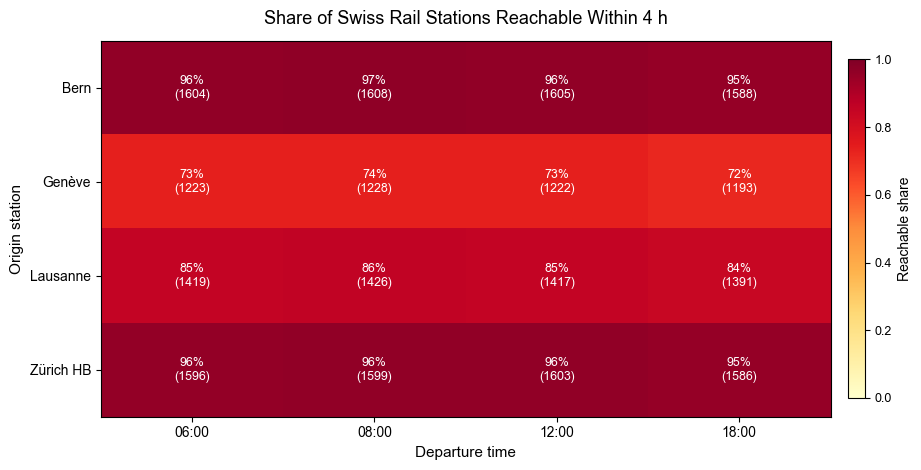

Comparison mode: Transit + walking


departure_label,06:00,08:00,12:00,18:00
origin,,,,
Bern,1604,1608,1605,1588
Genève,1223,1228,1222,1193
Lausanne,1419,1426,1417,1391
Zürich HB,1596,1599,1603,1586


In [9]:
import pandas as pd

from visualization import plot_reachability_comparison_heatmap

comparison_origins = ["Lausanne", "Bern", "Genève", "Zürich HB"]
comparison_departures = [6 * 60, 8 * 60, 12 * 60, 18 * 60]
comparison_horizon_minutes = 4 * 60
comparison_include_walking = True
comparison_rows = []

for origin_name in comparison_origins:
    origin_key, _origin_row = resolve_start_station(swiss_train_meta, swiss_train_meta, origin_name)
    origin_engine = ReachabilityEngine(
        swiss_train_meta,
        trip_instances,
        departures_by_station,
        departure_times_by_station,
        origin_key,
        walking_neighbors=walking_neighbors if comparison_include_walking else None,
    )

    for dep_minutes in comparison_departures:
        origin_rf = origin_engine.build_reachable_frame(dep_minutes, comparison_horizon_minutes)
        reachable_count = int(origin_rf["reachable"].sum())
        comparison_rows.append(
            {
                "origin": origin_name,
                "departure_minutes": dep_minutes,
                "departure_label": f"{dep_minutes // 60:02d}:00",
                "reachable_count": reachable_count,
                "reachable_share": reachable_count / len(swiss_train_meta),
            }
        )

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.sort_values(["departure_minutes", "reachable_share"], ascending=[True, False])

plot_reachability_comparison_heatmap(
    comparison_df,
    horizon_minutes=comparison_horizon_minutes,
)

mode_text = "Transit + walking" if comparison_include_walking else "Transit only"
print(f"Comparison mode: {mode_text}")

comparison_df.pivot(index="origin", columns="departure_label", values="reachable_count")

### Interpretation

This comparison adds a second analytical layer beyond the single-origin Lausanne example:

- Reachability depends not only on spatial position, but also on **origin station centrality** and **departure time**.
- The national perspective is strengthened by comparing major Swiss hubs rather than relying on a single-city case study.
- The modeling boundary remains explicit: the comparison is still **rail-only** and does not include local bus or tram feeders, nor explicit walking links.

In a later stage of the project, this matrix could support an interactive view combining origin selection, time windows, and map-based summaries.